# Modelo SVM

## 1. Imports y configuración inicial

In [ ]:
import pandas as pd
from pygments import lex
from pygments.lexers import get_lexer_by_name, guess_lexer
from pygments.util import ClassNotFound
from pygments.token import Name, Literal

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [ ]:
import seaborn as sns
import tiktoken

In [ ]:
INPUT_CSV = "filtered_H-AIRosettaMP.csv"
OUTPUT_CSV = "output_tokenized.csv"

CODE_COLUMN = "code"
LANG_COLUMN = None

LANG_MAP = {
    "python": "python",
    "java": "java",
    "c++": "cpp",
    "cpp": "cpp",
    "c#": "csharp",
    "csharp": "csharp",
    "js": "javascript",
    "javascript": "javascript"
}

## 2. Funciones necesarias

### 2.1. Funciones de tokenización

In [ ]:
def get_lexer(code, lang=None):
    if lang:
        lang = lang.lower()
        if lang in LANG_MAP:
            try:
                return get_lexer_by_name(LANG_MAP[lang])
            except ClassNotFound:
                pass

    try:
        return guess_lexer(code)
    except ClassNotFound:
        return None


def normalize_token(tok_type, tok_value):
    if tok_type in Name:
        return "VAR"
    elif tok_type in Literal:
        return "CONST"
    else:
        return tok_value


def tokenize_code(code, lang=None):
    lexer = get_lexer(code, lang)
    if lexer is None:
        return ""

    tokens = []
    for tok_type, tok_value in lex(code, lexer):
        tok_value = tok_value.strip()
        if tok_value:
            tokens.append(normalize_token(tok_type, tok_value))

    return " ".join(tokens)

### 2.2. Funciones de matriz de confusión

In [ ]:
def plot_confusion_matrices(y_val, y_pred_val, y_test, y_pred_test, model):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Validación
    cm_val = confusion_matrix(y_val, y_pred_val)
    disp_val = ConfusionMatrixDisplay(
        confusion_matrix=cm_val,
        display_labels=model.classes_
    )
    disp_val.plot(cmap='Blues', ax=axes[0], colorbar=False)
    axes[0].set_title('Matriz de Confusión - Validación')

    # Test
    cm_test = confusion_matrix(y_test, y_pred_test)
    disp_test = ConfusionMatrixDisplay(
        confusion_matrix=cm_test,
        display_labels=model.classes_
    )
    disp_test.plot(cmap='Blues', ax=axes[1], colorbar=False)
    axes[1].set_title('Matriz de Confusión - Test')

    plt.tight_layout()
    plt.show()

In [ ]:
def plot_confusion_matrix(X, y, model, title="Confusion Matrix"):
    y_pred = model.predict(X)
    cm = confusion_matrix(y, y_pred)
    cm = cm[::-1, ::-1]

    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Human", "AI"],
        yticklabels=["Human", "AI"]
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.show()

### 2.3. Funciones para modelo

In [ ]:
def split_data(X, y):
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y,
        test_size= 0.30,
        random_state=42
    )

    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp,
        test_size=0.50,
        random_state=42
    )

    print(f"Train: {len(X_train)}")
    print(f"Val:   {len(X_val)}")
    print(f"Test:  {len(X_test)}")

    return X_train, X_val, X_test, y_train, y_val, y_test

## 3. Modelo Intento 1

In [2]:
def main():
    df = pd.read_csv(INPUT_CSV)

    if CODE_COLUMN not in df.columns:
        raise ValueError(f"No existe la columna '{CODE_COLUMN}'")

    tokenized = []

    for i, row in df.iterrows():
        code = str(row[CODE_COLUMN])
        lang = str(row[LANG_COLUMN]) if LANG_COLUMN else None

        tokens = tokenize_code(code, lang)
        tokenized.append(tokens)

        if i % 1000 == 0:
            print(f"Procesados: {i}")


    df["tokens"] = tokenized
    df.to_csv(OUTPUT_CSV, index=False)

    print("✅ Tokenización completada")

if __name__ == "__main__":
    main()

Procesados: 0
Procesados: 1000
Procesados: 2000
Procesados: 3000
Procesados: 4000
Procesados: 5000
Procesados: 6000
Procesados: 7000
Procesados: 8000
Procesados: 9000
Procesados: 10000
✅ Tokenización completada


In [4]:
df = pd.read_csv(OUTPUT_CSV)
df.head()

,task_name,language_name,code,target,set,tokens
0,Array concatenation,Java,import java.util.Vector;\nimport java.util.Ite...,Ai_generated,Java_from_C++,import VAR VAR VAR VAR VAR ; import VAR VAR VA...
1,Array length,Java,public class Main {\n public static void ma...,Ai_generated,Java_from_C++,public class Main {\n public static void ma...
2,Arithmetic/Integer,Java,import java.util.Scanner;\n\npublic class Main...,Ai_generated,Java_from_C++,import VAR VAR VAR VAR VAR ; VAR class VAR { V...
3,Arithmetic-geometric mean/Calculate Pi,Java,import java.math.BigDecimal;\nimport java.math...,Ai_generated,Java_from_C++,import VAR VAR VAR VAR VAR ; import VAR VAR VA...
4,Arithmetic/Rational,Java,import java.math.BigInteger;\nimport java.util...,Ai_generated,Java_from_C++,import VAR VAR VAR VAR VAR ; import VAR VAR VA...


In [ ]:
df = df.dropna(subset=['tokens'])
df = df[df['tokens'] != '']

X = df['tokens']
y = df['target']

X_train, X_val, X_test, y_train, y_val, y_test = split_data(X, y)

vectorizer = TfidfVectorizer(max_features=1000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf   = vectorizer.transform(X_val)
X_test_tfidf  = vectorizer.transform(X_test)

modelo = LinearSVC(random_state=42, max_iter=2000)
modelo.fit(X_train_tfidf, y_train)

print("\n--- VALIDACIÓN ---")
y_pred_val = modelo.predict(X_val_tfidf)
print(f"Accuracy: {accuracy_score(y_val, y_pred_val):.4f}")
print(classification_report(y_val, y_pred_val))

print("\n--- TEST ---")
y_pred_test = modelo.predict(X_test_tfidf)
print(f"Accuracy: {accuracy_score(y_test, y_pred_test):.4f}")
print(classification_report(y_test, y_pred_test))

Train: 7613
Val:   1631
Test:  1632

--- VALIDACIÓN ---
Accuracy: 0.6965
               precision    recall  f1-score   support

 Ai_generated       0.71      0.96      0.81      1118
Human_written       0.58      0.13      0.21       513

     accuracy                           0.70      1631
    macro avg       0.64      0.54      0.51      1631
 weighted avg       0.67      0.70      0.62      1631


--- TEST ---
Accuracy: 0.6900
               precision    recall  f1-score   support

 Ai_generated       0.70      0.96      0.81      1106
Human_written       0.58      0.13      0.21       526

     accuracy                           0.69      1632
    macro avg       0.64      0.54      0.51      1632
 weighted avg       0.66      0.69      0.62      1632



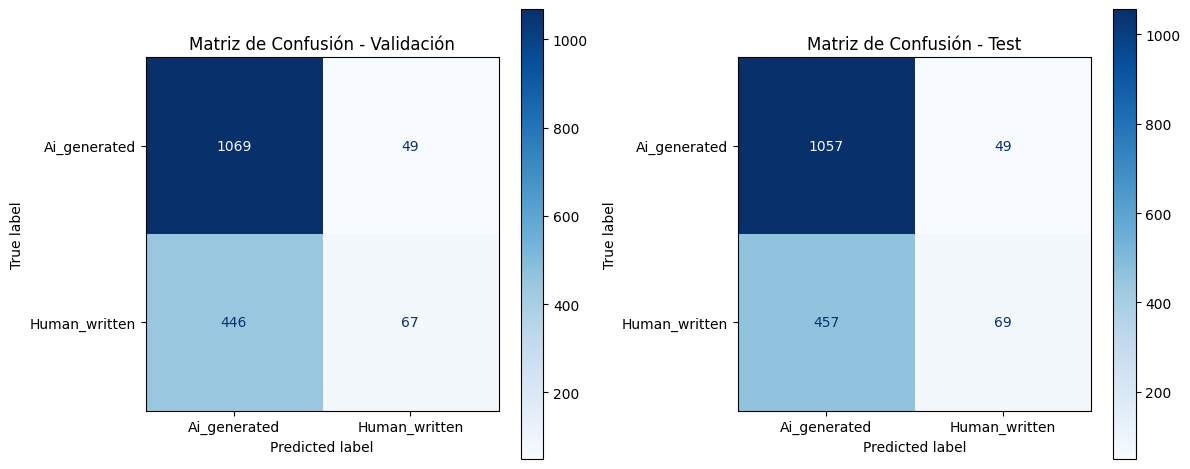

In [ ]:
plot_confusion_matrices(
    y_val, y_pred_val,
    y_test, y_pred_test,
    modelo
)

## 4. Modelo CON duplicados

In [ ]:
def main():
    df = pd.read_csv(INPUT_CSV)

    if CODE_COLUMN not in df.columns:
        raise ValueError(f"No existe la columna '{CODE_COLUMN}'")

    tokenized = []

    for i, row in df.iterrows():
        code = str(row[CODE_COLUMN])
        lang = str(row[LANG_COLUMN]) if LANG_COLUMN else None

        tokens = tokenize_code(code, lang)
        tokenized.append(tokens)

        if i % 1000 == 0:
            print(f"Procesados: {i}")


    df["tokens"] = tokenized
    df.to_csv(OUTPUT_CSV, index=False)

    print("✅ Tokenización completada")

if __name__ == "__main__":
    main()

Procesados: 0
Procesados: 1000
Procesados: 2000
Procesados: 3000
Procesados: 4000
Procesados: 5000
Procesados: 6000
Procesados: 7000
Procesados: 8000
Procesados: 9000
Procesados: 10000
Procesados: 11000
Procesados: 12000
Procesados: 13000
Procesados: 14000
Procesados: 15000
Procesados: 16000
Procesados: 17000
Procesados: 18000
Procesados: 19000
Procesados: 20000
Procesados: 21000
Procesados: 22000
Procesados: 23000
Procesados: 24000
Procesados: 25000
Procesados: 26000
Procesados: 27000
Procesados: 28000
Procesados: 29000
Procesados: 30000
Procesados: 31000
Procesados: 32000
Procesados: 33000
Procesados: 34000
Procesados: 35000
Procesados: 36000
Procesados: 37000
Procesados: 38000
Procesados: 39000
Procesados: 40000
Procesados: 41000
Procesados: 42000
Procesados: 43000
Procesados: 44000
Procesados: 45000
Procesados: 46000
Procesados: 47000
Procesados: 48000
Procesados: 49000
Procesados: 50000
Procesados: 51000
Procesados: 52000
Procesados: 53000
Procesados: 54000
Procesados: 55000
Proce

In [ ]:
df = pd.read_csv(OUTPUT_CSV)
df.head()

,task_url,task_name,task_description,language_name,code,target,set,tokens
0,http://rosettacode.org/wiki/Array_concatenation,Array concatenation,Task\n\nShow how to concatenate two arrays in ...,Java,import java.util.Vector;\nimport java.util.Ite...,Ai_generated,Java_from_C++,import VAR VAR VAR VAR VAR ; import VAR VAR VA...
1,http://rosettacode.org/wiki/Array_length,Array length,Task\n\nDetermine the amount of elements in an...,Java,public class Main {\n public static void ma...,Ai_generated,Java_from_C++,public class Main {\n public static void ma...
2,http://rosettacode.org/wiki/Arithmetic/Integer,Arithmetic/Integer,\nBasic Data Operation\n\nThis is a basic data...,Java,import java.util.Scanner;\n\npublic class Main...,Ai_generated,Java_from_C++,import VAR VAR VAR VAR VAR ; VAR class VAR { V...
3,http://rosettacode.org/wiki/Arithmetic-geometr...,Arithmetic-geometric mean/Calculate Pi,Almkvist Berndt 1988 begins with an investigat...,Java,import java.math.BigDecimal;\nimport java.math...,Ai_generated,Java_from_C++,import VAR VAR VAR VAR VAR ; import VAR VAR VA...
4,http://rosettacode.org/wiki/Arithmetic/Rational,Arithmetic/Rational,Task\n\nCreate a reasonably complete implement...,Java,import java.math.BigInteger;\nimport java.util...,Ai_generated,Java_from_C++,import VAR VAR VAR VAR VAR ; import VAR VAR VA...


In [ ]:
OUTPUT_CSV = "output2_tokenized.csv"

df = df.dropna(subset=['tokens'])
df = df[df['tokens'] != '']

X = df['tokens']
y = df['target']

X_train, X_val, X_test, y_train, y_val, y_test = split_data(X, y)

vectorizer = TfidfVectorizer(max_features=1000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf   = vectorizer.transform(X_val)
X_test_tfidf  = vectorizer.transform(X_test)

modelo = LinearSVC(random_state=42, max_iter=2000)
modelo.fit(X_train_tfidf, y_train)

print("\n--- VALIDACIÓN ---")
y_pred_val = modelo.predict(X_val_tfidf)
print(f"Accuracy: {accuracy_score(y_val, y_pred_val):.4f}")
print(classification_report(y_val, y_pred_val))

print("\n--- TEST ---")
y_pred_test = modelo.predict(X_test_tfidf)
print(f"Accuracy: {accuracy_score(y_test, y_pred_test):.4f}")
print(classification_report(y_test, y_pred_test))

Train: 84843
Val:   18181
Test:  18181

--- VALIDACIÓN ---
Accuracy: 0.6046
               precision    recall  f1-score   support

 Ai_generated       0.59      0.66      0.63      9087
Human_written       0.62      0.54      0.58      9094

     accuracy                           0.60     18181
    macro avg       0.61      0.60      0.60     18181
 weighted avg       0.61      0.60      0.60     18181


--- TEST ---
Accuracy: 0.6073
               precision    recall  f1-score   support

 Ai_generated       0.60      0.67      0.63      9143
Human_written       0.62      0.55      0.58      9038

     accuracy                           0.61     18181
    macro avg       0.61      0.61      0.61     18181
 weighted avg       0.61      0.61      0.61     18181



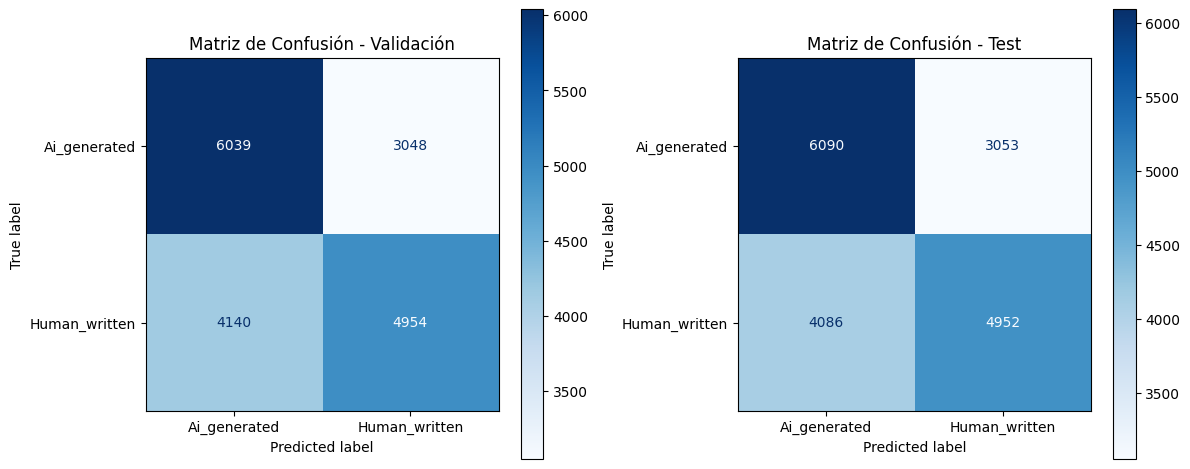

In [ ]:
plot_confusion_matrices(
    y_val, y_pred_val,
    y_test, y_pred_test,
    modelo
)

## 5. Modelo con balanceo de clases

In [ ]:
OUTPUT_CSV = "output3_tokenized.csv"

def main():
    df = pd.read_csv(INPUT_CSV)

    if CODE_COLUMN not in df.columns:
        raise ValueError(f"No existe la columna '{CODE_COLUMN}'")

    tokenized = []

    for i, row in df.iterrows():
        code = str(row[CODE_COLUMN])
        lang = str(row[LANG_COLUMN]) if LANG_COLUMN else None

        tokens = tokenize_code(code, lang)
        tokenized.append(tokens)

        if i % 1000 == 0:
            print(f"Procesados: {i}")


    df["tokens"] = tokenized
    df.to_csv(OUTPUT_CSV, index=False)

    print("✅ Tokenización completada")

if __name__ == "__main__":
    main()

Procesados: 0
Procesados: 1000
Procesados: 2000
Procesados: 3000
Procesados: 4000
Procesados: 5000
Procesados: 6000
Procesados: 7000
Procesados: 8000
Procesados: 9000
Procesados: 10000
✅ Tokenización completada


In [ ]:
df = pd.read_csv(OUTPUT_CSV)
df.head()

,task_name,language_name,code,target,set,tokens
0,Array concatenation,Java,import java.util.Vector;\nimport java.util.Ite...,Ai_generated,Java_from_C++,import VAR VAR VAR VAR VAR ; import VAR VAR VA...
1,Array length,Java,public class Main {\n public static void ma...,Ai_generated,Java_from_C++,public class Main {\n public static void ma...
2,Arithmetic/Integer,Java,import java.util.Scanner;\n\npublic class Main...,Ai_generated,Java_from_C++,import VAR VAR VAR VAR VAR ; VAR class VAR { V...
3,Arithmetic-geometric mean/Calculate Pi,Java,import java.math.BigDecimal;\nimport java.math...,Ai_generated,Java_from_C++,import VAR VAR VAR VAR VAR ; import VAR VAR VA...
4,Arithmetic/Rational,Java,import java.math.BigInteger;\nimport java.util...,Ai_generated,Java_from_C++,import VAR VAR VAR VAR VAR ; import VAR VAR VA...


In [ ]:
df = df.dropna(subset=['tokens'])
df = df[df['tokens'] != '']

X = df['tokens']
y = df['target']

X_train, X_val, X_test, y_train, y_val, y_test = split_data(X, y)

vectorizer = TfidfVectorizer(max_features=1000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf   = vectorizer.transform(X_val)
X_test_tfidf  = vectorizer.transform(X_test)

modelo = LinearSVC(
    random_state=42,
    max_iter=2000,
    class_weight='balanced'
)
modelo.fit(X_train_tfidf, y_train)

print("\n--- VALIDACIÓN ---")
y_pred_val = modelo.predict(X_val_tfidf)
print(f"Accuracy: {accuracy_score(y_val, y_pred_val):.4f}")
print(classification_report(y_val, y_pred_val))

print("\n--- TEST ---")
y_pred_test = modelo.predict(X_test_tfidf)
print(f"Accuracy: {accuracy_score(y_test, y_pred_test):.4f}")
print(classification_report(y_test, y_pred_test))

Train: 7613
Val:   1631
Test:  1632

--- VALIDACIÓN ---
Accuracy: 0.6370
               precision    recall  f1-score   support

 Ai_generated       0.77      0.68      0.72      1118
Human_written       0.44      0.55      0.49       513

     accuracy                           0.64      1631
    macro avg       0.60      0.61      0.60      1631
 weighted avg       0.66      0.64      0.65      1631


--- TEST ---
Accuracy: 0.6201
               precision    recall  f1-score   support

 Ai_generated       0.74      0.68      0.71      1106
Human_written       0.42      0.49      0.45       526

     accuracy                           0.62      1632
    macro avg       0.58      0.59      0.58      1632
 weighted avg       0.64      0.62      0.63      1632



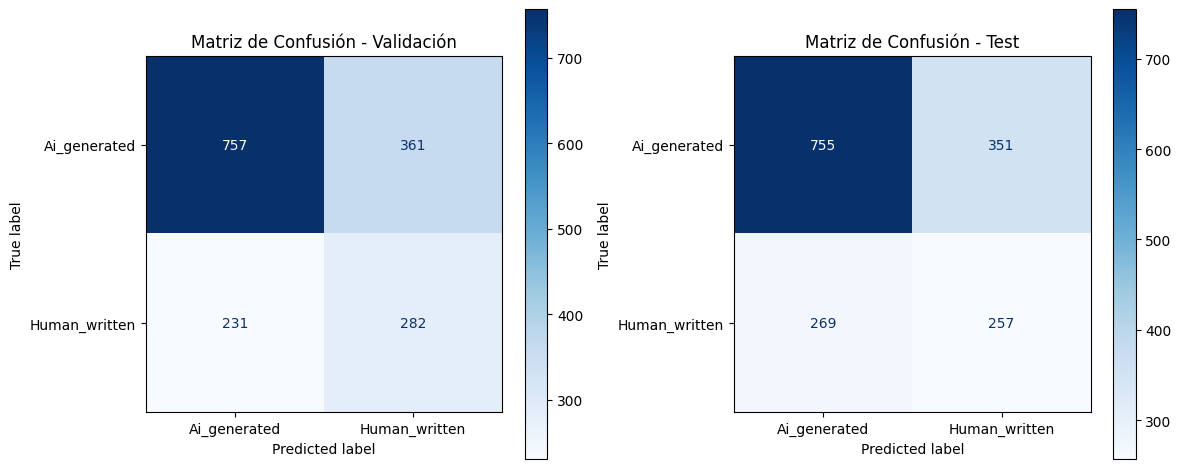

In [ ]:
plot_confusion_matrices(
    y_val, y_pred_val,
    y_test, y_pred_test,
    modelo
)

## 6. Modelo sin normalizar tokens

In [ ]:
OUTPUT_CSV = "output_tokenized-sin-tokenizar.csv"

def get_lexer(code, lang=None):
    if lang:
        lang = lang.lower()
        if lang in LANG_MAP:
            try:
                return get_lexer_by_name(LANG_MAP[lang])
            except ClassNotFound:
                pass

    try:
        return guess_lexer(code)
    except ClassNotFound:
        return None


def normalize_token(tok_type, tok_value):
    return tok_value


def tokenize_code(code, lang=None):
    lexer = get_lexer(code, lang)
    if lexer is None:
        return ""

    tokens = []
    for tok_type, tok_value in lex(code, lexer):
        tok_value = tok_value.strip()
        if tok_value:
            tokens.append(normalize_token(tok_type, tok_value))

    return " ".join(tokens)

def main():
    df = pd.read_csv(INPUT_CSV)

    if CODE_COLUMN not in df.columns:
        raise ValueError(f"No existe la columna '{CODE_COLUMN}'")

    tokenized = []

    for i, row in df.iterrows():
        code = str(row[CODE_COLUMN])
        lang = str(row[LANG_COLUMN]) if LANG_COLUMN else None

        tokens = tokenize_code(code, lang)
        tokenized.append(tokens)

        if i % 1000 == 0:
            print(f"Procesados: {i}")


    df["tokens"] = tokenized
    df.to_csv(OUTPUT_CSV, index=False)

    print("✅ Tokenización completada")

if __name__ == "__main__":
    main()

Procesados: 0
Procesados: 1000
Procesados: 2000
Procesados: 3000
Procesados: 4000
Procesados: 5000
Procesados: 6000
Procesados: 7000
Procesados: 8000
Procesados: 9000
Procesados: 10000
✅ Tokenización completada


In [ ]:
df = pd.read_csv(OUTPUT_CSV)
df.head()

,task_name,language_name,code,target,set,tokens
0,Array concatenation,Java,import java.util.Vector;\nimport java.util.Ite...,Ai_generated,Java_from_C++,import java . util . Vector ; import java . ut...
1,Array length,Java,public class Main {\n public static void ma...,Ai_generated,Java_from_C++,public class Main {\n public static void ma...
2,Arithmetic/Integer,Java,import java.util.Scanner;\n\npublic class Main...,Ai_generated,Java_from_C++,import java . util . Scanner ; public class Ma...
3,Arithmetic-geometric mean/Calculate Pi,Java,import java.math.BigDecimal;\nimport java.math...,Ai_generated,Java_from_C++,import java . math . BigDecimal ; import java ...
4,Arithmetic/Rational,Java,import java.math.BigInteger;\nimport java.util...,Ai_generated,Java_from_C++,import java . math . BigInteger ; import java ...


In [ ]:
df = df.dropna(subset=['tokens'])
df = df[df['tokens'] != '']

X = df['tokens']
y = df['target']

X_train, X_val, X_test, y_train, y_val, y_test = split_data(X, y)

vectorizer = TfidfVectorizer(max_features=1000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf   = vectorizer.transform(X_val)
X_test_tfidf  = vectorizer.transform(X_test)

modelo = LinearSVC(random_state=42, max_iter=50000)
modelo.fit(X_train_tfidf, y_train)

print("\n--- VALIDACIÓN ---")
y_pred_val = modelo.predict(X_val_tfidf)
print(f"Accuracy: {accuracy_score(y_val, y_pred_val):.4f}")
print(classification_report(y_val, y_pred_val))

print("\n--- TEST ---")
y_pred_test = modelo.predict(X_test_tfidf)
print(f"Accuracy: {accuracy_score(y_test, y_pred_test):.4f}")
print(classification_report(y_test, y_pred_test))

Train: 7613
Val:   1631
Test:  1632

--- VALIDACIÓN ---
Accuracy: 0.7394
               precision    recall  f1-score   support

 Ai_generated       0.77      0.89      0.82      1118
Human_written       0.63      0.41      0.50       513

     accuracy                           0.74      1631
    macro avg       0.70      0.65      0.66      1631
 weighted avg       0.72      0.74      0.72      1631


--- TEST ---
Accuracy: 0.7243
               precision    recall  f1-score   support

 Ai_generated       0.76      0.88      0.81      1106
Human_written       0.61      0.40      0.49       526

     accuracy                           0.72      1632
    macro avg       0.68      0.64      0.65      1632
 weighted avg       0.71      0.72      0.71      1632



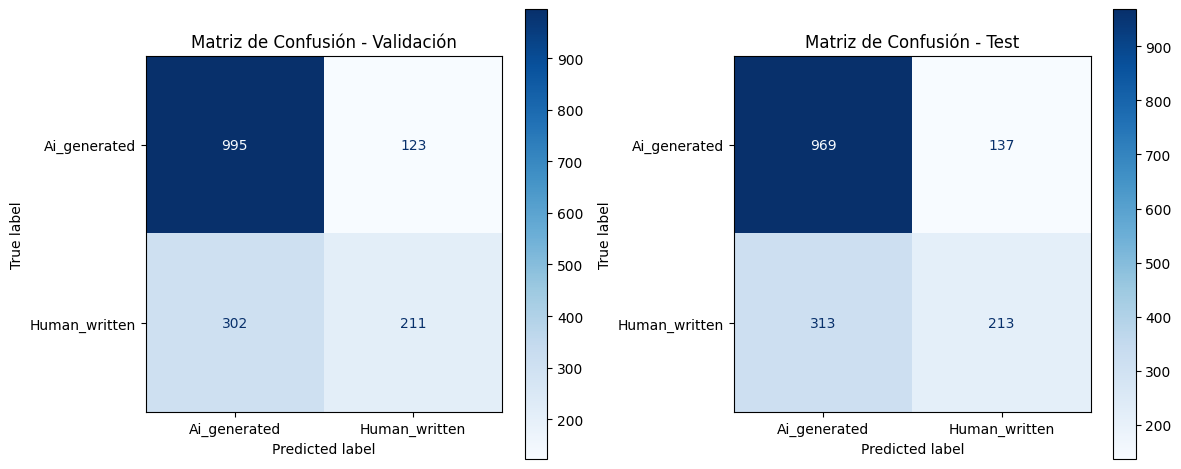

In [ ]:
plot_confusion_matrices(
    y_val, y_pred_val,
    y_test, y_pred_test,
    modelo
)

## 7. Modelo sin tokenizar-nat y dataset completo

In [ ]:
OUTPUT_CSV = "outputfinal_tokenized.csv"

def get_lexer(code, lang=None):
    if lang:
        lang = lang.lower()
        if lang in LANG_MAP:
            try:
                return get_lexer_by_name(LANG_MAP[lang])
            except ClassNotFound:
                pass

    try:
        return guess_lexer(code)
    except ClassNotFound:
        return None


def normalize_token(tok_type, tok_value):
    if tok_type in Name:
        return "VAR"
    elif tok_type in Literal:
        return "CONST"
    else:
        return tok_value


def tokenize_code(code, lang=None):
    lexer = get_lexer(code, lang)
    if lexer is None:
        return ""

    tokens = []
    for tok_type, tok_value in lex(code, lexer):
        tok_value = tok_value.strip()
        if tok_value:
            tokens.append(normalize_token(tok_type, tok_value))

    return " ".join(tokens)


def main():
    df = pd.read_csv(INPUT_CSV)

    if CODE_COLUMN not in df.columns:
        raise ValueError(f"No existe la columna '{CODE_COLUMN}'")

    tokenized = []

    for i, row in df.iterrows():
        code = str(row[CODE_COLUMN])
        lang = str(row[LANG_COLUMN]) if LANG_COLUMN else None

        tokens = tokenize_code(code, lang)
        tokenized.append(tokens)

        if i % 1000 == 0:
            print(f"Procesados: {i}")


    df["tokens"] = tokenized
    df.to_csv(OUTPUT_CSV, index=False)

    print("Tokenización completada")

if __name__ == "__main__":
    main()

Procesados: 0
Procesados: 1000
Procesados: 2000
Procesados: 3000
Procesados: 4000
Procesados: 5000
Procesados: 6000
Procesados: 7000
Procesados: 8000
Procesados: 9000
Procesados: 10000
Procesados: 11000
Procesados: 12000
Procesados: 13000
Procesados: 14000
Procesados: 15000
Procesados: 16000
Procesados: 17000
Procesados: 18000
Procesados: 19000
Procesados: 20000
Procesados: 21000
Procesados: 22000
Procesados: 23000
Procesados: 24000
Procesados: 25000
Procesados: 26000
Procesados: 27000
Procesados: 28000
Procesados: 29000
Procesados: 30000
Procesados: 31000
Procesados: 32000
Procesados: 33000
Procesados: 34000
Procesados: 35000
Procesados: 36000
Procesados: 37000
Procesados: 38000
Procesados: 39000
Procesados: 40000
Procesados: 41000
Procesados: 42000
Procesados: 43000
Procesados: 44000
Procesados: 45000
Procesados: 46000
Procesados: 47000
Procesados: 48000
Procesados: 49000
Procesados: 50000
Procesados: 51000
Procesados: 52000
Procesados: 53000
Procesados: 54000
Procesados: 55000
Proce

In [ ]:
df = pd.read_csv(OUTPUT_CSV)
df.head()

,task_url,task_name,task_description,language_name,code,target,set,tokens
0,http://rosettacode.org/wiki/Array_concatenation,Array concatenation,Task\n\nShow how to concatenate two arrays in ...,Java,import java.util.Vector;\nimport java.util.Ite...,Ai_generated,Java_from_C++,import VAR VAR VAR VAR VAR ; import VAR VAR VA...
1,http://rosettacode.org/wiki/Array_length,Array length,Task\n\nDetermine the amount of elements in an...,Java,public class Main {\n public static void ma...,Ai_generated,Java_from_C++,public class Main {\n public static void ma...
2,http://rosettacode.org/wiki/Arithmetic/Integer,Arithmetic/Integer,\nBasic Data Operation\n\nThis is a basic data...,Java,import java.util.Scanner;\n\npublic class Main...,Ai_generated,Java_from_C++,import VAR VAR VAR VAR VAR ; VAR class VAR { V...
3,http://rosettacode.org/wiki/Arithmetic-geometr...,Arithmetic-geometric mean/Calculate Pi,Almkvist Berndt 1988 begins with an investigat...,Java,import java.math.BigDecimal;\nimport java.math...,Ai_generated,Java_from_C++,import VAR VAR VAR VAR VAR ; import VAR VAR VA...
4,http://rosettacode.org/wiki/Arithmetic/Rational,Arithmetic/Rational,Task\n\nCreate a reasonably complete implement...,Java,import java.math.BigInteger;\nimport java.util...,Ai_generated,Java_from_C++,import VAR VAR VAR VAR VAR ; import VAR VAR VA...


In [ ]:
df = df.dropna(subset=['tokens'])
df = df[df['tokens'] != '']

X = df['tokens']
y = df['target']

X_train, X_val, X_test, y_train, y_val, y_test = split_data(X, y)

vectorizer = TfidfVectorizer(max_features=1000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf   = vectorizer.transform(X_val)
X_test_tfidf  = vectorizer.transform(X_test)

modelo = LinearSVC(random_state=42, max_iter=50000)
modelo.fit(X_train_tfidf, y_train)

print("\n--- VALIDACIÓN ---")
y_pred_val = modelo.predict(X_val_tfidf)
print(f"Accuracy: {accuracy_score(y_val, y_pred_val):.4f}")
print(classification_report(y_val, y_pred_val))

print("\n--- TEST ---")
y_pred_test = modelo.predict(X_test_tfidf)
print(f"Accuracy: {accuracy_score(y_test, y_pred_test):.4f}")
print(classification_report(y_test, y_pred_test))

Train: 84843
Val:   18181
Test:  18181

--- VALIDACIÓN ---
Accuracy: 0.6046
               precision    recall  f1-score   support

 Ai_generated       0.59      0.66      0.63      9087
Human_written       0.62      0.54      0.58      9094

     accuracy                           0.60     18181
    macro avg       0.61      0.60      0.60     18181
 weighted avg       0.61      0.60      0.60     18181


--- TEST ---
Accuracy: 0.6073
               precision    recall  f1-score   support

 Ai_generated       0.60      0.67      0.63      9143
Human_written       0.62      0.55      0.58      9038

     accuracy                           0.61     18181
    macro avg       0.61      0.61      0.61     18181
 weighted avg       0.61      0.61      0.61     18181



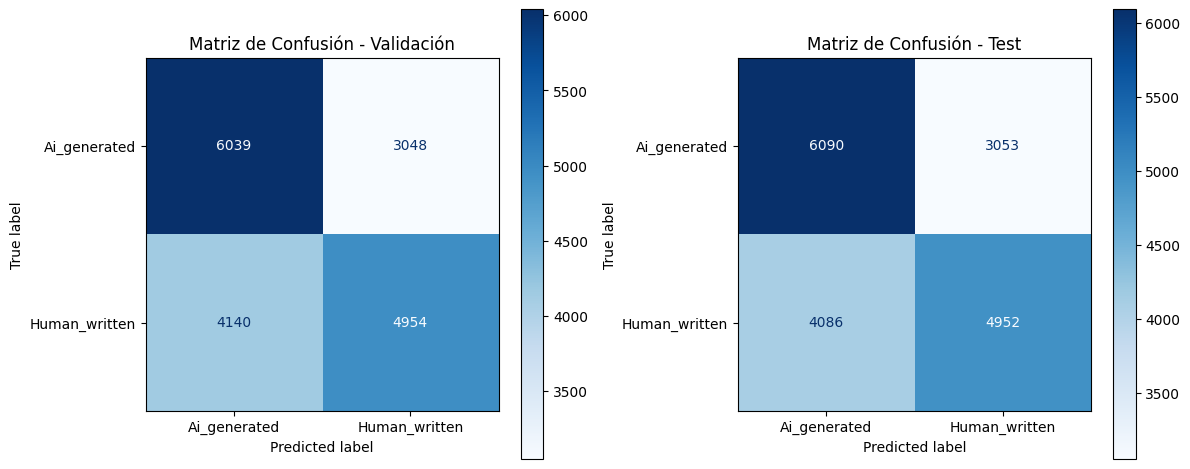

In [ ]:
plot_confusion_matrices(
    y_val, y_pred_val,
    y_test, y_pred_test,
    modelo
)

## 8. Modelo No tokenización pygments

In [ ]:
df_clean = df.dropna(subset=['code'])
df_clean = df_clean[df_clean['code'] != '']

X = df_clean['code'] 
y = df_clean['target']

X_train, X_val, X_test, y_train, y_val, y_test = split_data(X, y)

vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf   = vectorizer.transform(X_val)
X_test_tfidf  = vectorizer.transform(X_test)

modelo = LinearSVC(
    random_state=42,
    max_iter=2000,
    class_weight='balanced'
)
modelo.fit(X_train_tfidf, y_train)

print("\n--- VALIDACIÓN ---")
y_pred_val = modelo.predict(X_val_tfidf)
print(f"Accuracy: {accuracy_score(y_val, y_pred_val):.4f}")
print(classification_report(y_val, y_pred_val))

print("\n--- TEST ---")
y_pred_test = modelo.predict(X_test_tfidf)
print(f"Accuracy: {accuracy_score(y_test, y_pred_test):.4f}")
print(classification_report(y_test, y_pred_test))

Train: 84843
Val:   18181
Test:  18181

--- VALIDACIÓN ---
Accuracy: 0.7041
               precision    recall  f1-score   support

 Ai_generated       0.71      0.68      0.70      9087
Human_written       0.70      0.73      0.71      9094

     accuracy                           0.70     18181
    macro avg       0.70      0.70      0.70     18181
 weighted avg       0.70      0.70      0.70     18181


--- TEST ---
Accuracy: 0.7117
               precision    recall  f1-score   support

 Ai_generated       0.72      0.69      0.71      9143
Human_written       0.70      0.73      0.72      9038

     accuracy                           0.71     18181
    macro avg       0.71      0.71      0.71     18181
 weighted avg       0.71      0.71      0.71     18181



## 9. Modelo tokenización con tiktoken

In [ ]:
df = pd.read_csv("filtered_H-AIRosettaMP.csv")
df.head()

,task_name,language_name,code,target,set
0,Array concatenation,Java,import java.util.Vector;\nimport java.util.Ite...,Ai_generated,Java_from_C++
1,Array length,Java,public class Main {\n public static void ma...,Ai_generated,Java_from_C++
2,Arithmetic/Integer,Java,import java.util.Scanner;\n\npublic class Main...,Ai_generated,Java_from_C++
3,Arithmetic-geometric mean/Calculate Pi,Java,import java.math.BigDecimal;\nimport java.math...,Ai_generated,Java_from_C++
4,Arithmetic/Rational,Java,import java.math.BigInteger;\nimport java.util...,Ai_generated,Java_from_C++


Tokenizando...
✅ Tokenización completada
import  java .util .Vector ;
 import  java .util .Iterator ;
  
 public  class  Vector Test 
 {
    public  static  void  main (String []  args )
    {
      Vector <Integer >  a  =  new  Vector <Integer >( 3 );
      Vector <Integer >  b  =  new  Vector <Integer >( 4 );
      a .add ( 11 );  a .add ( 12 );  a .add ( 13 );
      b .add ( 21 );  b .add ( 22 );  b .add ( 23 );  b .add ( 24 );
  
      a .addAll (b );
  
      for  ( int  i  =   0 ;  i  <  a .size ();  ++ i )
        System .out .println (" a ["  +  i  +  "]  =  "  +  a .get (i ));
    }
 }

Train: 7613
Val:   1631
Test:  1632

--- VALIDACIÓN ---
Accuracy: 0.6616
               precision    recall  f1-score   support

 Ai_generated       0.77      0.72      0.74      1118
Human_written       0.47      0.54      0.50       513

     accuracy                           0.66      1631
    macro avg       0.62      0.63      0.62      1631
 weighted avg       0.68      0.66      0.67   

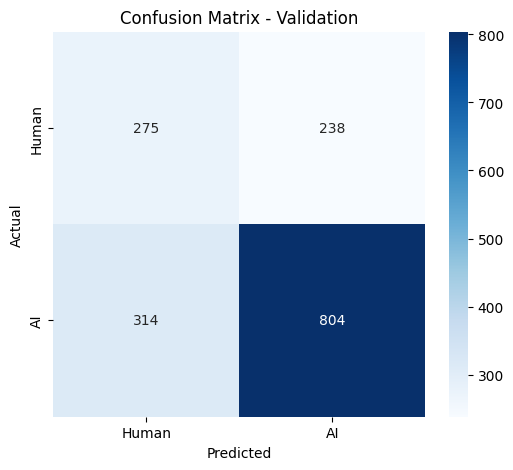

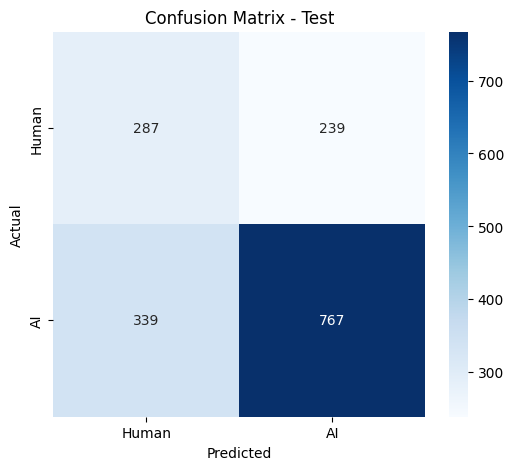

In [ ]:
def tokenize_with_tiktoken(code):
    try:
        enc = tiktoken.get_encoding("cl100k_base")
        tokens = enc.encode(code)
        token_strings = [enc.decode([t]) for t in tokens]
        return " ".join(token_strings)
    except:
        return ""


print("Tokenizando...")
df['tokens_tiktoken'] = df['code'].apply(tokenize_with_tiktoken)
print("✅ Tokenización completada")
print(df['tokens_tiktoken'].iloc[0])

# SVM + TF-IDF
df_clean = df.dropna(subset=['tokens_tiktoken'])
df_clean = df_clean[df_clean['tokens_tiktoken'] != '']

X = df_clean['tokens_tiktoken']
y = df_clean['target']

X_train, X_val, X_test, y_train, y_val, y_test = split_data(X, y)

vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf   = vectorizer.transform(X_val)
X_test_tfidf  = vectorizer.transform(X_test)

modelo = LinearSVC(
    random_state=42,
    max_iter=2000,
    class_weight='balanced'
)
modelo.fit(X_train_tfidf, y_train)

print("\n--- VALIDACIÓN ---")
y_pred_val = modelo.predict(X_val_tfidf)
print(f"Accuracy: {accuracy_score(y_val, y_pred_val):.4f}")
print(classification_report(y_val, y_pred_val))

print("\n--- TEST ---")
y_pred_test = modelo.predict(X_test_tfidf)
print(f"Accuracy: {accuracy_score(y_test, y_pred_test):.4f}")
print(classification_report(y_test, y_pred_test))

plot_confusion_matrix(
    X_val_tfidf,
    y_val,
    modelo,
    title="Confusion Matrix - Validation"
)

plot_confusion_matrix(
    X_test_tfidf,
    y_test,
    modelo,
    title="Confusion Matrix - Test"
)